# Doing a Linear regression without Scikit Learn

There's nothing better to understand the gradient descent algorithm than to code it from scratch. It may seem difficult at first glance but don't worry, we will guide you step by step. It is also a fantastic occasion to practice python key concepts like **Classes**!

Don't hesitate to come back to your Machine Learning course on linear regression to refresh your memory. 

Our goal will be to code a simple linear regression such as : 

$f(x) = \beta_1 \times x + \beta_0$

* Import the following libraries: 
  * Numpy 

In [137]:
import numpy as np 

* Define a `Model` class that will take two methods: 
  1. `__init__(self)`, the class builder which will allow you to define an attribute $\beta_0$ (`beta_0` in your code) and an attribute $\beta_1$ (`beta_1` in your code). These attributes represent the coefficients/parameters of the model an we will be initialize them randomly using Numpy (cf: `np.random.randn`).
  2. `__call__(self, x)`, a special method that will turn our class into a callable which will return $\beta_1 \times x + \beta_0$ when called.

In [138]:
class Model():
    def __init__(self, beta_0, beta_1):
        self.beta_0 = beta_0
        self.beta_1 = beta_1

    def __call__(self, x):
        return self.beta_1 * x + self.beta_0

* Create an instance of your class `Model`

In [139]:
b0 = np.random.randn()
b1 = np.random.randn()

lr = Model(beta_0=b0, beta_1=b1)

In [140]:
print(b1)

-1.9460690239188219


In [141]:
b0

-0.42932566254527493

* Try doing a first "regression" by running `model(3.0)`. 
NB: If you don't have the same values as this notebook in output, this is normal since you have initialized your values randomly. 

In [142]:
lr(3.0)

-6.26753273430174

* This value corresponds to a random prediction of your model. But we don't have any data yet. This time, let's use `sklearn` to import data. 
  * Import `sklearn.datasets`
  * Use the `load_diabetes()` function to load the diebetes dataset in an object called `diabetes`.
  * Print the `DESCR` attribute of the diabetes object
  * Save the content of the `data` attribute in an object named `diabetes_data`
  * Save the content of the `target` attribute in an object named `y`

In [143]:
import sklearn.datasets as datasets

diabetes = datasets.load_diabetes()
print(diabetes.DESCR)

diabetes_data = diabetes.data
y = diabetes.target

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

* We have too much data in this dataset `diabetes_data`, take only the third column of the dataset and store it in a `diabetes_X` variable.

In [144]:
diabetes_X = diabetes_data[:, 2:3]

In [145]:
diabetes_X[:5]

array([[ 0.06169621],
       [-0.05147406],
       [ 0.04445121],
       [-0.01159501],
       [-0.03638469]])

* Visualize your data using `plotly`.

In [146]:
len(diabetes_X)

442

In [147]:
diabetes_X.shape

(442, 1)

In [148]:
y.shape

(442,)

In [149]:
len(y)

442

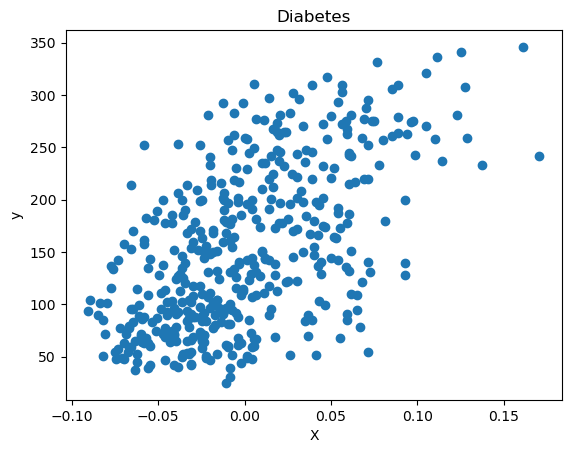

In [170]:
import matplotlib.pyplot as plt

plt.scatter(x=diabetes_X, y=y)
plt.title("Diabetes")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [151]:
# import plotly.express as px

# fig = px.scatter(x=diabetes_X.flatten(), y=y)
# fig.show()


* Now we need to define a cost function. For a linear regression, we could use MSE :

`np.mean((model(input) - y)**2)`

  * Create this function which we'll call `mse` (for mean square error). This function will take two arguments `y_pred` & `y_true`.

In [152]:
def mse(y_pred, y_true):
    return np.mean((lr(y_pred) - y_true)**2)

mse = mse(diabetes_X, y)

* Test your function by inserting `model(diabetes_X)` & `y` as arguments. 
* Calculate the rmse as well

In [153]:
rmse = np.sqrt(mse)
print(f"MSE : {mse}")
print(f"RMSE : {rmse}")

MSE : 29205.304407035168
RMSE : 170.89559504865878


* Visualize your regression in relation to your points 

In [154]:
# beta_1 = covariance(x,y) / variance(x)
# beta_0 = mean(y) - beta_1 * mean(x)
# np.cov(x, y) matrice 2x2 :
# [0, 0] = variance de x
# [0, 1] = covariance entre x et y
# [1, 0] = covariance entre x et y (identique à [0,1])
# [1, 1] = variance de y
x_flat = diabetes_X.flatten()
beta_1 = np.cov(x_flat, y)[0, 1] / np.var(x_flat)
beta_0 = np.mean(y) - beta_1 * np.mean(x_flat)
print(beta_1)
print(beta_0)

951.5881748066782
152.13348416289617


In [155]:
lr.beta_1 = beta_1
lr.beta_0 = beta_0

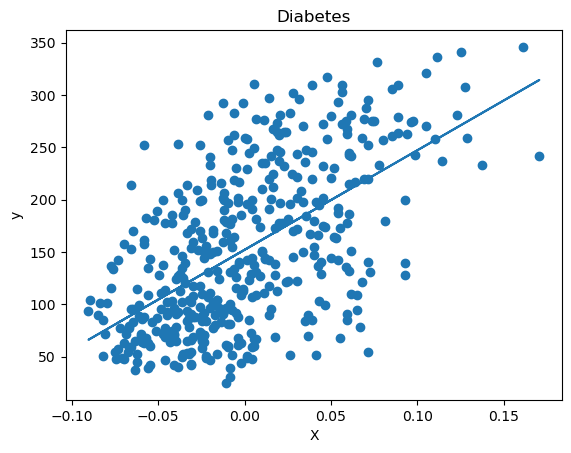

In [169]:
plt.scatter(x=diabetes_X, y=y)
plt.plot(diabetes_X, lr(diabetes_X))
plt.title("Diabetes")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [157]:
# fig = px.scatter(x=diabetes_X.flatten(), y=y, trendline="ols")
# fig.show()

* We're going to need to compute the gradients for our variable `model.beta_1` and our constant `model.beta_0`. To do this, we're going to need to review our derivative formulas. Since we're not here to do math, we're going to give you these formulas. 
  * `derive_model_beta_1 = 2/len(y_pred)*np.sum((x @ (y_pred - y_true)))`
  * `derive_model_beta_0 = 2/len(y_pred)*(np.sum(y_pred - y_true))`

  * Feel free to read this article if you want to know more about the calculation of the derivative: [Gradient Descent Derivation](https://mccormickml.com/2014/03/04/gradient-descent-derivation/)


  * So using the above formulas, code the first function `derivative_mse_beta_1` that will take the arguments: 
    * `x` --> the values for your variable / `y_pred` --> the values predicted by your model / `y_true` --> the values of the target variable


In [158]:
y_pred = lr(diabetes_X)
y_true = y
x = diabetes_X.flatten()

derive_model_beta_1 = 2/len(y_pred)*np.sum((x @ (y_pred - y_true)))

derive_model_beta_0 = 2/len(y_pred)*(np.sum(y_pred - y_true))


* Test you function

In [159]:
print(derive_model_beta_1)
print(derive_model_beta_0)

1903.1763496133565
2.2124178808738745e-11


* So using the above formulas, now code the `derivative_mse_beta_0` function which will take the arguments :
    * `y_pred` --> the values predicted by your model / `y_true` --> the actual values to predict

In [160]:
learning_rate = 0.1

# Modifier les paramètres existants
beta_0 = lr.beta_0 - learning_rate * derive_model_beta_0
beta_1 = lr.beta_1 - learning_rate * derive_model_beta_1

* Test you function

In [161]:
print(beta_0)
print(beta_1)

152.13348416289395
761.2705398453426


* We will try to see if we can minimize our cost function using the two gradients above. To update our variables, we need to subtract their respective gradients. Ex: 
  * `param = param - learning_rate * gradient`

  * Set a `learning_rate` to 0.1
  * Try to apply your formula on `model.beta_1` and `model.beta_0`.

In [162]:
print(f"OLD model.a = {lr.beta_0}")
print(f"OLD model.b = {lr.beta_1}")
print(f"NEW model.a = {beta_0}")
print(f"New model.b = {beta_1}")

OLD model.a = 152.13348416289617
OLD model.b = 951.5881748066782
NEW model.a = 152.13348416289395
New model.b = 761.2705398453426


Wesee that the values of the two parameters have changed, let's see how it affected the predictions of the model. 
Visualize the data vs the model's predictions.

We notice the predictions got a little closer to our real data
* Recalculate your MSE

In [167]:
mse

np.float64(29205.304407035168)

In [ ]:
y_pred_nouveau = lr(diabetes_X)
nouveau_mse = np.mean((y_pred_nouveau - y)**2)
nouveau_mse

np.float64(7978.572802864919)

* Our MSE has dropped a lot! This is good news but the process of gradient descent is iterative. So you'll have to do it several times before arriving at accurate predictions. 
  * By making a loop, try to repeat the process from above 10,000 times. 
  * Display every 1000 epochs: mse, model.beta_1 & model.beta_0 

-------------------- Epoch 0 --------------------
Current Loss: 29214.856625242403
beta_1 = [-1.8063269]
beta_0 = [30.08339534]
-------------------- Epoch 1000 --------------------
Current Loss: 4719.232033282504
beta_1 = [344.46640766]
beta_0 = [152.13348416]
-------------------- Epoch 2000 --------------------
Current Loss: 4225.669891599262
beta_1 = [564.68829636]
beta_0 = [152.13348416]
-------------------- Epoch 3000 --------------------
Current Loss: 4026.0397049990993
beta_1 = [704.7446029]
beta_0 = [152.13348416]
-------------------- Epoch 4000 --------------------
Current Loss: 3945.295644552924
beta_1 = [793.81735185]
beta_0 = [152.13348416]
-------------------- Epoch 5000 --------------------
Current Loss: 3912.637240489043
beta_1 = [850.46567279]
beta_0 = [152.13348416]
-------------------- Epoch 6000 --------------------
Current Loss: 3899.427954875885
beta_1 = [886.49276643]
beta_0 = [152.13348416]
-------------------- Epoch 7000 --------------------
Current Loss: 3894.08

* Using `plotly`, view your model and actual values again

**We've got a nice regression this time!** 